In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from sklearn.base import RegressorMixin, BaseEstimator
from sklearn.utils.validation import validate_data, check_is_fitted


class BaseLinearRegression(RegressorMixin, BaseEstimator):
    def __init__(self, fit_intercept=True):
        self.fit_intercept = fit_intercept
    def predict(self, X):
        check_is_fitted(self)
        X = validate_data(
            self,
            X,
            reset=False,
            dtype=float,
        )
        predictions = X@self.coef_ + self.intercept_
        return predictions

In [5]:
class MyLinearRegressionClosedForm(BaseLinearRegression):
    def fit(self,X,y):
        if(self.fit_intercept):
            one = np.ones((X.shape[0],1))
            ones_X = np.concatenate((one, X),axis = 1)
        else:
            ones_X = X
        weights = np.linalg.lstsq(ones_X,y,rcond = None)[0]
        if self.fit_intercept:
            self.intercept_ = weights[0]
            self.coef_ = weights[1:]
        else:
            self.intercept_ = 0
            self.coef_ = weights
        return self
class MyLinearRegressionBatchGD(BaseLinearRegression):
    def __init__(self,fit_intercept = True, num_epochs = 100,learning_rate = 0.01):
        super().__init__(fit_intercept = fit_intercept)
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
    def fit(self,X,y):
        if(self.fit_intercept):
            one = np.ones((X.shape[0],1))
            ones_X = np.concatenate((one, X),axis = 1)
        else:
            ones_X = X
        weights = np.zeros(ones_X.shape[1])
        self.loss_history_ = []
        for i in range(self.num_epochs):
            loss = 1/2 * np.mean((y - ones_X @ weights)**2)
            self.loss_history_.append(loss)
            dW = - ones_X.T @ (y - ones_X @ weights) / X.shape[0]
            weights -= self.learning_rate * dW
            print(f"Epochs {i} || Loss: {loss}")
        if self.fit_intercept:
            self.intercept_ = weights[0]
            self.coef_ = weights[1:]
        else:
            self.intercept_ = 0
            self.coef_ = weights
        return self
class MyLinearRegressionMiniBatchGD(BaseLinearRegression):
    def __init__(self,random_state = None,fit_intercept = True, num_epochs = 100, learning_rate = 0.01, batch_size = 32):
        super().__init__(fit_intercept = fit_intercept)
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.random_state = random_state
    def fit(self, X, y):
        if(self.fit_intercept):
            one = np.ones((X.shape[0],1))
            ones_X = np.concatenate((one,X), axis = 1)
        else:
            ones_X = X

        weights = np.zeros(ones_X.shape[1])
        self.batch_loss_history_ = []
        rng = np.random.default_rng(self.random_state)
        for i in range(self.num_epochs):
            permutations = rng.permutation(ones_X.shape[0])
            ones_X_shuffle = ones_X[permutations]
            y_shuffle = y[permutations]
            for start in range(0, X.shape[0] , self.batch_size):
                end = start + self.batch_size
                X_batch = ones_X_shuffle[start: end]
                y_batch = y_shuffle[start: end]

                loss = 1 / 2 * np.mean((y_batch - X_batch@weights)**2)
                self.batch_loss_history_.append(loss)

                dw = - X_batch.T @ (y_batch - X_batch@weights) / len(X_batch)
                weights -= dw * self.learning_rate
        if(self.fit_intercept):
            self.intercept_ = weights[0]
            self.coef_ = weights[1:]
        else:
            self.intercept_ =  0
            self.coef_= weights
        return self
class MyLinearRegressionSGD(BaseLinearRegression):
    def __init__(self,fit_intercept = True, num_epochs = 100, learning_rate = 0.01):
        super().__init__(fit_intercept = fit_intercept)
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
    def fit(self,X,y):
        if(self.fit_intercept):
            one = np.ones((X.shape[0],1))
            ones_X = np.concatenate((one,X) , axis = 1)
        else:
            ones_X = X

        weights = np.zeros(ones_X.shape[1])
        self.loss_history_= []

        for i in range(self.num_epochs):
            for j in range(ones_X.shape[0]):
                loss = 1/2 * (y[j] - ones_X[j] @ weights)**2
                self.loss_history_.append(loss)
                dw = -ones_X[j] * (y[j] - ones_X[j] @ weights)
                weights -= self.learning_rate*dw
        if(self.fit_intercept):
            self.coef_ = weights[1:]
            self.intercept_ = weights[0]
        else:
            self.coef_ = weights
            self.intercept_ = 0
        return self

In [6]:
class MyStandardScaler():
    def __init__(self):
        self.mean_ = None
        self.scale_ = None
    def fit(self,data):
        self.mean_ = data.mean(axis = 0)
        self.scale_ = data.std(axis = 0)
        self.scale_[np.where(self.scale_ == 0)] = 1
        return self
    def transform(self,data):
        if self.mean_ is None or self.scale_ is None:
            raise RuntimeError("Scaler chưa được fit !!!")
        return (data - self.mean_) / self.scale_
    def fit_transform(self,data):
        return self.fit(data).transform(data)
    def reverse_transform(self,data):
        if self.mean_ is None or self.scale_ is None:
            raise RuntimeError("Scaler chưa được fit !!!")
        return data * self.scale_ + self.mean_

[ 3.4154161 -3.8727492] 4.999999822255192


Text(0, 0.5, 'Loss')

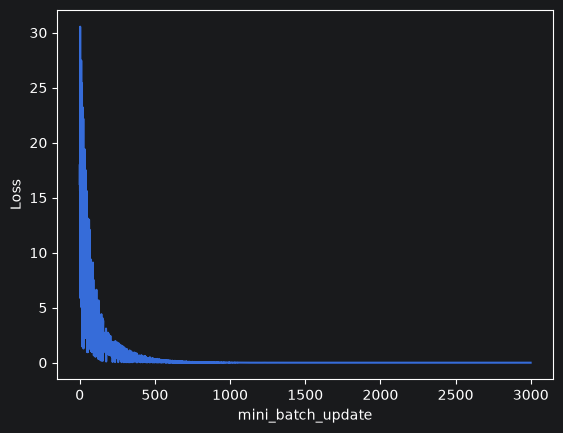

In [8]:
X = np.array([
    [1.0, 2.0],
    [2.0, 0.0],
    [3.0, 1.0],
    [4.0, 3.0],
    [5.0, 2.0],
    [6.0, 4.0],
])

y = (
    2 * X[:, 0]
    - 3 * X[:, 1]
    + 4
)
scaler_X = MyStandardScaler()
X = scaler_X.fit_transform(X)
model = MyLinearRegressionMiniBatchGD(num_epochs=1000, batch_size = 2)
model.fit(X,y)
print(model.coef_, model.intercept_)
plt.plot(model.batch_loss_history_)
plt.xlabel("mini_batch_update")
plt.ylabel("Loss")


Text(0, 0.5, 'Loss')

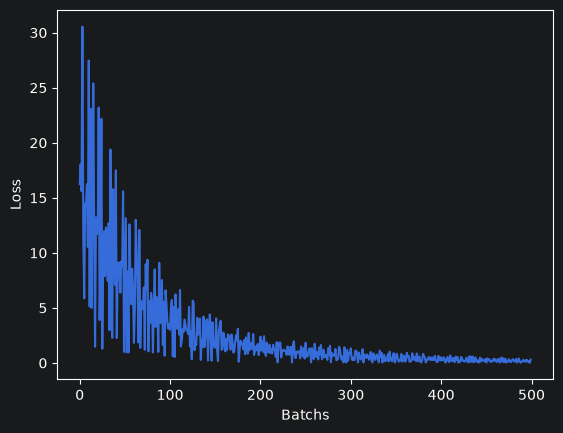

In [9]:
start = 0
end = 500
loss_segment = model.batch_loss_history_[start:end]
plt.plot(range(start,end), loss_segment)
plt.xlabel("Batchs")
plt.ylabel("Loss")

In [ ]:
X = np.array([[1,2,3,4],
              [5,6,7,8]])
y = np.array([5,6,7,8])
print(X[0]@y)

In [ ]:
import numpy as np
a = np.array([[1,2],[3,4], [5,6],[7,8]])
permutations = np.random.permutation(a.shape[0])
a_shuffle = a[permutations, :]
print(a_shuffle)

In [ ]:
import numpy as np
rng = np.random.default_rng(45)

permutations = rng.permutation(a.shape[0])
a_shuffle = a[permutations, :]
print(a_shuffle)

In [ ]:
import numpy as np
A = np.array([[1,2,3],
              [4,5,6],
              [7,8,9]])
B = (A - A.mean(axis = 0))/A.std(axis = 0)
print(B * A.std(axis = 0) + A.mean(axis = 0))

In [ ]:
A = np.array([1,2,3,4,0])
A[np.where(A == 0)] = 1
print(np.where(A == 1))
b = np.array([1.1,2.2,3.3,4.4,5.5])
print((A-b) / 2.0)

In [ ]:
y = np.array([1,2,3,4])
y = y.reshape(-1,1)
print(y)
print(y.reshape(-1,))


## Train_test_split

In [1]:
def my_train_test_split(X, y, test_size, random_state = None, shuffle = True):
    num_samples = X.shape[0]
    n_test = int(np.ceil(num_samples * test_size))
    n_train = num_samples - n_test
    indices = np.arange(num_samples)
    if (shuffle):
        rng = np.random.default_rng(random_state)
        rng.shuffle(indices)
    train_indices = indices[:n_train]
    X_train = X[train_indices]
    y_train = y[train_indices]
    test_indices = indices[n_train:]
    X_test = X[test_indices]
    y_test = y[test_indices]
    return X_train, X_test, y_train, y_test

---

# Early Stopping (Dừng sớm)

**Early Stopping** là một kỹ thuật regularization phổ biến trong Machine Learning và Deep Learning, giúp ngăn ngừa hiện tượng quá khớp (**Overfitting**) và tiết kiệm tài nguyên tính toán.

---

## 1. Cơ chế hoạt động

Trong suốt quá trình huấn luyện, mô hình thực hiện các bước sau tại **mỗi epoch**:

1. **Huấn luyện:** Cập nhật trọng số trên *Training set*.
2. **Đánh giá:** Tính toán *Loss* trên *Validation set*.
3. **So sánh:** Đối chiếu *Validation loss* vừa tính được với *Best loss* đã lưu trước đó.
4. **Cập nhật:**
   * Nếu có sự cải thiện tốt hơn $\rightarrow$ Lưu lại trạng thái trọng số (*Weights*) mới này.
5. **Kiểm tra điều kiện dừng:**
   * Nếu *Validation loss* không cải thiện trong một số lượng epoch liên tiếp vượt quá ngưỡng cho phép $\rightarrow$ **Dừng quá trình huấn luyện**.

---

## 2. Các tham số quan trọng

| Tham số | Ý nghĩa & Vai trò |
| :--- | :--- |
| **`patience`** | Số lượng epoch tối đa cho phép mô hình *không cải thiện* trước khi chính thức kích hoạt lệnh dừng. |
| **`min_delta`** | Ngưỡng cải thiện tối thiểu. Mức giảm của *Loss* phải lớn hơn `min_delta` thì mới được tính là một sự cải thiện hợp lệ. |
| **`restore_best_weights`** | Nếu thiết lập `True`, mô hình sẽ tự động khôi phục lại bộ trọng số (*Weights*) tại epoch có kết quả tốt nhất thay vì giữ lại trọng số ở epoch cuối cùng. |

---


In [ ]:
def compute_weights():
    pass
def compute_val_loss():
    pass
patience = 10
epochs = 100
best_weights = None
min_delta = 1e-4
best_val_loss = float("inf")
epochs_without_improve = 0
for epoch in range(epochs):
    weights = compute_weights()

    val_loss = compute_val_loss()

    if (val_loss < best_val_loss - min_delta):
        best_val_loss = val_loss
        best_weights = weights.copy()
    else:
        epochs_without_improve += 1
    if(epochs_without_improve == patience):
        print("Early Stopping")
        break
weights = best_weights
